# Exploración Inicial — Señales EEG/EMG

Este notebook analiza el dataset `datos_eeg_emg.csv` generado desde `Data.txt`.

**Estructura del dataset:**
| Columna | Tipo | Descripción |
|---------|------|-------------|
| `Tiempo_s` | float | Vector de tiempo en segundos (0.001 s de paso → 1000 Hz) |
| `EEG_1` | float | Canal EEG principal |
| `EEG_2` | float | Canal EEG secundario |
| `EMG_1..4` | float | Canales EMG musculares (4 canales) |

**Canales clave según el pipeline:**
- Para detección de **marcadores de movimiento**: un canal **EMG** (burst detector)
- Para análisis de **BP y desincronización beta**: los canales **EEG**

> **Nota reunión 09-04:** el pipeline es → detectar bursts EMG → usar como marcadores → cortar EEG → buscar BP (onda lenta pre-movimiento) y caída en banda Beta (13–30 Hz)

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal
from scipy.stats import kurtosis, skew
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (14, 4)

DATA_PATH = '../data/datos_eeg_emg.csv'
SRATE = 1000  # Hz

## 1. Carga y descripción general

In [62]:
df = pd.read_csv(DATA_PATH)

print(f'Muestras  : {len(df):,}')
print(f'Columnas  : {list(df.columns)}')
print(f'Duración  : {df.Tiempo_s.iloc[-1]:.1f} s  ({df.Tiempo_s.iloc[-1]/60:.1f} min)')
print(f'Frec.     : {SRATE} Hz')
print()

df.describe().round(4)

Muestras  : 304,011
Columnas  : ['Tiempo_s', 'EEG_1', 'EEG_2', 'EMG_1', 'EMG_2', 'EMG_3', 'EMG_4', 'EMG_5', 'EMG_6']
Duración  : 304.0 s  (5.1 min)
Frec.     : 1000 Hz



,Tiempo_s,EEG_1,EEG_2,EMG_1,EMG_2,EMG_3,EMG_4,EMG_5,EMG_6
count,304011.0000,304011.0000,304011.0000,304011.0000,304011.0000,304011.0000,304011.0000,304011.0000,304011.0000
mean,152.0050,0.2200,0.4410,-0.0117,-0.0239,-0.0161,-0.0213,-0.0209,-0.0251
std,87.7606,0.2592,0.4052,0.0241,0.0198,0.0075,0.0118,0.0024,0.0027
min,0.0000,-1.5869,-1.9883,-0.6875,-0.8919,-0.2200,-0.4557,-0.0704,-0.1778
25%,76.0025,0.0638,0.1973,-0.0137,-0.0253,-0.0172,-0.0225,-0.0217,-0.0261
50%,152.0050,0.2189,0.3779,-0.0115,-0.0236,-0.0158,-0.0210,-0.0207,-0.0249
75%,228.0075,0.3764,0.5962,-0.0100,-0.0226,-0.0150,-0.0201,-0.0199,-0.0240
max,304.0100,1.6181,2.6732,0.8581,0.5395,0.5102,0.7209,0.0273,0.0552


## 2. Señal completa — todos los canales

Vista rápida para detectar artefactos, saturaciones o canales ruidosos.

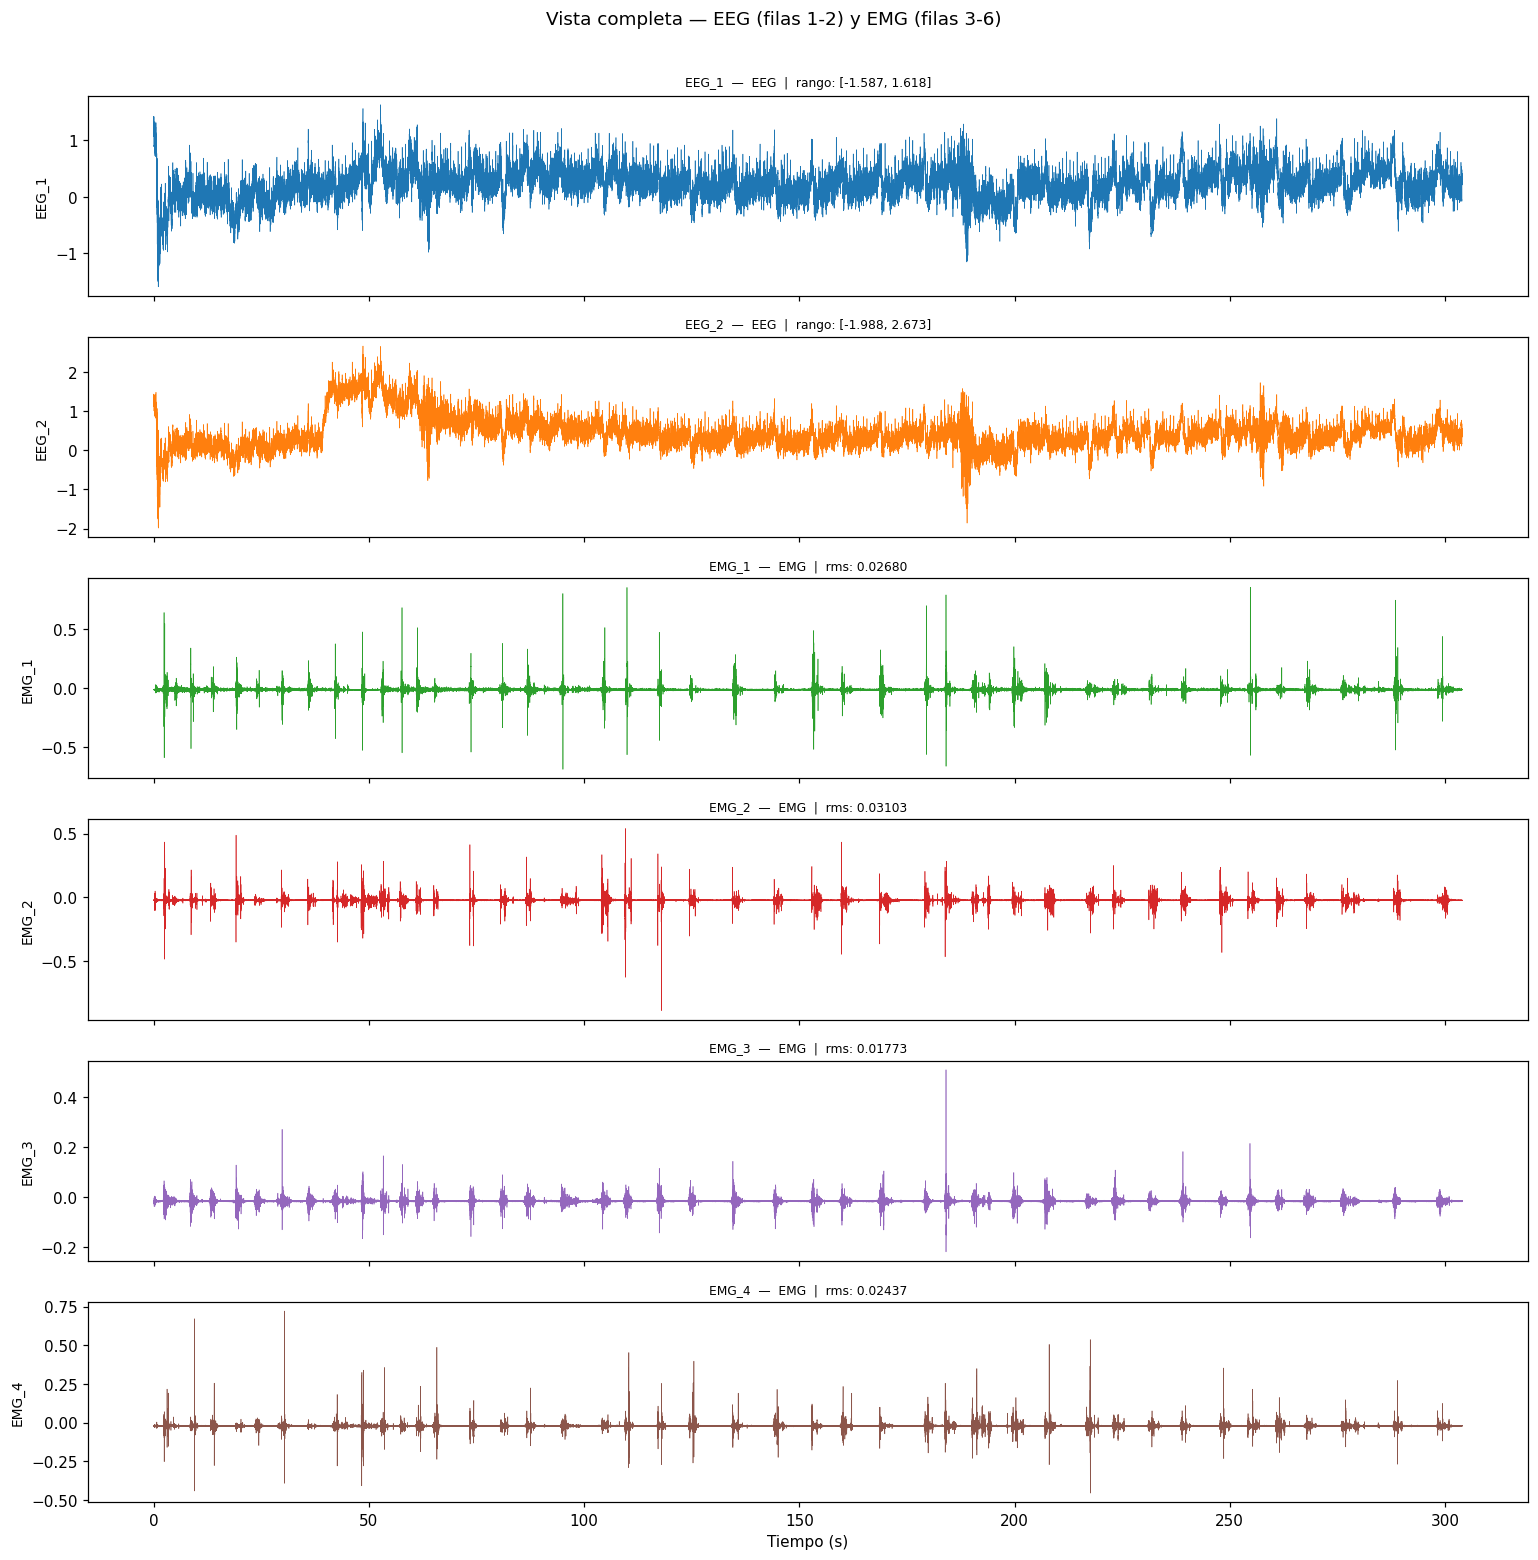

In [63]:
eeg_cols = ['EEG_1', 'EEG_2']
emg_cols = ['EMG_1', 'EMG_2', 'EMG_3', 'EMG_4']
t = df['Tiempo_s'].values

fig, axes = plt.subplots(6, 1, figsize=(14, 14), sharex=True)

colors_eeg = ['#1f77b4', '#ff7f0e']
colors_emg = ['#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i, col in enumerate(eeg_cols):
    axes[i].plot(t, df[col].values, color=colors_eeg[i], lw=0.4)
    axes[i].set_ylabel(col, fontsize=9)
    axes[i].set_title(f'{col}  —  EEG  |  rango: [{df[col].min():.3f}, {df[col].max():.3f}]', fontsize=8)

for j, col in enumerate(emg_cols):
    axes[j+2].plot(t, df[col].values, color=colors_emg[j], lw=0.4)
    axes[j+2].set_ylabel(col, fontsize=9)
    axes[j+2].set_title(f'{col}  —  EMG  |  rms: {np.sqrt(np.mean(df[col].values**2)):.5f}', fontsize=8)

axes[-1].set_xlabel('Tiempo (s)')
plt.suptitle('Vista completa — EEG (filas 1-2) y EMG (filas 3-6)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 3. Estadísticas por canal

Comparar RMS, rango, kurtosis y skewness para identificar cuáles canales tienen mejor señal.

In [64]:
signal_cols = eeg_cols + emg_cols
stats = []
for col in signal_cols:
    x = df[col].values
    stats.append({
        'Canal'    : col,
        'Tipo'     : 'EEG' if col.startswith('EEG') else 'EMG',
        'Media'    : np.mean(x),
        'Std'      : np.std(x),
        'RMS'      : np.sqrt(np.mean(x**2)),
        'Min'      : np.min(x),
        'Max'      : np.max(x),
        'Rango'    : np.max(x) - np.min(x),
        'Kurtosis' : kurtosis(x),
        'Skewness' : skew(x),
    })

stats_df = pd.DataFrame(stats).set_index('Canal')
stats_df.round(5)

,Tipo,Media,Std,RMS,Min,Max,Rango,Kurtosis,Skewness
Canal,,,,,,,,,
EEG_1,EEG,0.21999,0.25917,0.33994,-1.58685,1.61813,3.20498,1.41194,-0.08795
EEG_2,EEG,0.44101,0.40517,0.59887,-1.98828,2.67319,4.66147,2.37574,1.10931
EMG_1,EMG,-0.01174,0.02409,0.02680,-0.68748,0.85808,1.54556,174.88060,-1.75788
EMG_2,EMG,-0.02390,0.01980,0.03103,-0.89191,0.53949,1.43140,132.11382,0.75444
EMG_3,EMG,-0.01608,0.00747,0.01773,-0.21997,0.51025,0.73022,134.09738,1.28910
EMG_4,EMG,-0.02133,0.01179,0.02437,-0.45569,0.72089,1.17658,320.74184,1.99845


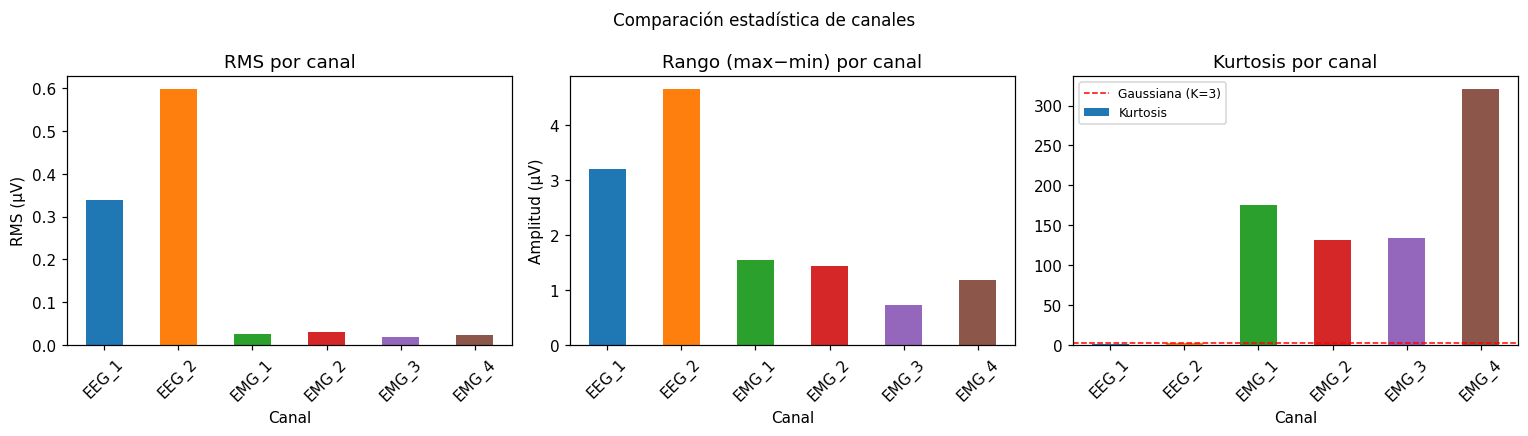

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

colors = colors_eeg + colors_emg

stats_df['RMS'].plot(kind='bar', ax=axes[0], color=colors, title='RMS por canal')
axes[0].set_ylabel('RMS (µV)')
axes[0].tick_params(axis='x', rotation=45)

stats_df['Rango'].plot(kind='bar', ax=axes[1], color=colors, title='Rango (max−min) por canal')
axes[1].set_ylabel('Amplitud (µV)')
axes[1].tick_params(axis='x', rotation=45)

stats_df['Kurtosis'].plot(kind='bar', ax=axes[2], color=colors, title='Kurtosis por canal')
axes[2].axhline(3, color='red', lw=1, ls='--', label='Gaussiana (K=3)')
axes[2].legend(fontsize=8)
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Comparación estadística de canales', fontsize=11)
plt.tight_layout()
plt.show()

## 4. Densidad espectral de potencia (PSD)

Ver en qué bandas concentra energía cada canal. Para EEG nos interesan las **bandas alfa (8–13 Hz) y beta (13–30 Hz)**. Alta kurtosis en EMG indica bursts musculares.

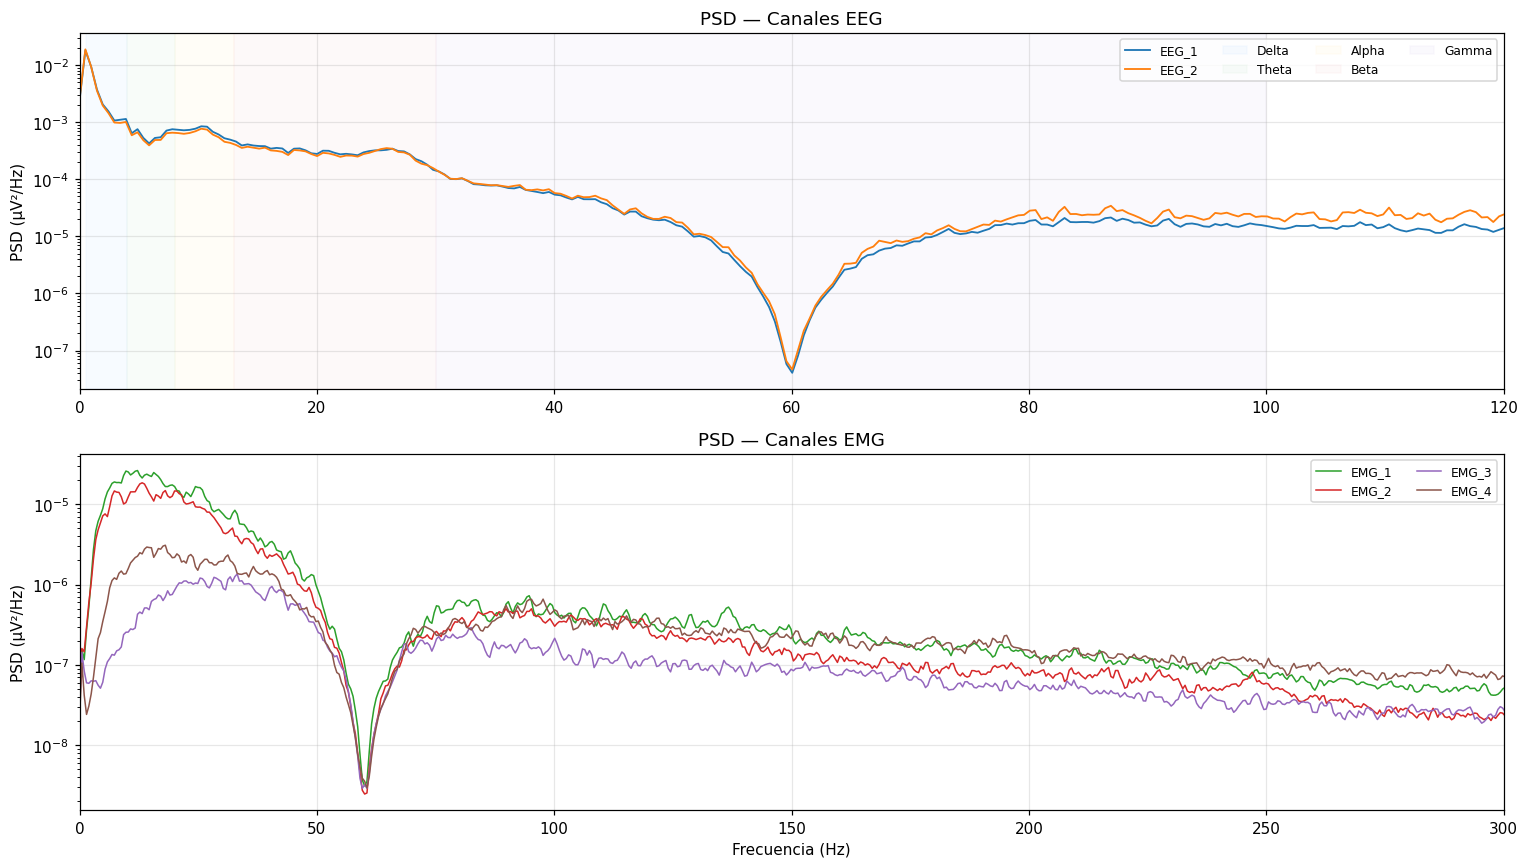

In [66]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# EEG PSD
for i, col in enumerate(eeg_cols):
    x = df[col].values
    freqs, psd = signal.welch(x, SRATE, nperseg=2048)
    axes[0].semilogy(freqs, psd, label=col, lw=1.2, color=colors_eeg[i])

bandas = [('Delta', 0.5, 4, '#cce5ff'), ('Theta', 4, 8, '#d4edda'),
          ('Alpha', 8, 13, '#fff3cd'), ('Beta', 13, 30, '#f8d7da'), ('Gamma', 30, 100, '#e2d9f3')]
for nombre, lo, hi, color in bandas:
    axes[0].axvspan(lo, hi, alpha=0.15, color=color, label=nombre)

axes[0].set_xlim(0, 120)
axes[0].set_title('PSD — Canales EEG')
axes[0].set_ylabel('PSD (µV²/Hz)')
axes[0].legend(fontsize=8, ncol=4)
axes[0].grid(True, alpha=0.3)

# EMG PSD
for j, col in enumerate(emg_cols):
    x = df[col].values
    freqs, psd = signal.welch(x, SRATE, nperseg=2048)
    axes[1].semilogy(freqs, psd, label=col, lw=1, color=colors_emg[j])

axes[1].set_xlim(0, 300)
axes[1].set_title('PSD — Canales EMG')
axes[1].set_xlabel('Frecuencia (Hz)')
axes[1].set_ylabel('PSD (µV²/Hz)')
axes[1].legend(fontsize=8, ncol=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Zoom: primeros 10 segundos

Ver la morfología de la señal a nivel de muestra para detectar ruido de línea (50 Hz), artefactos de movimiento o saturaciones.

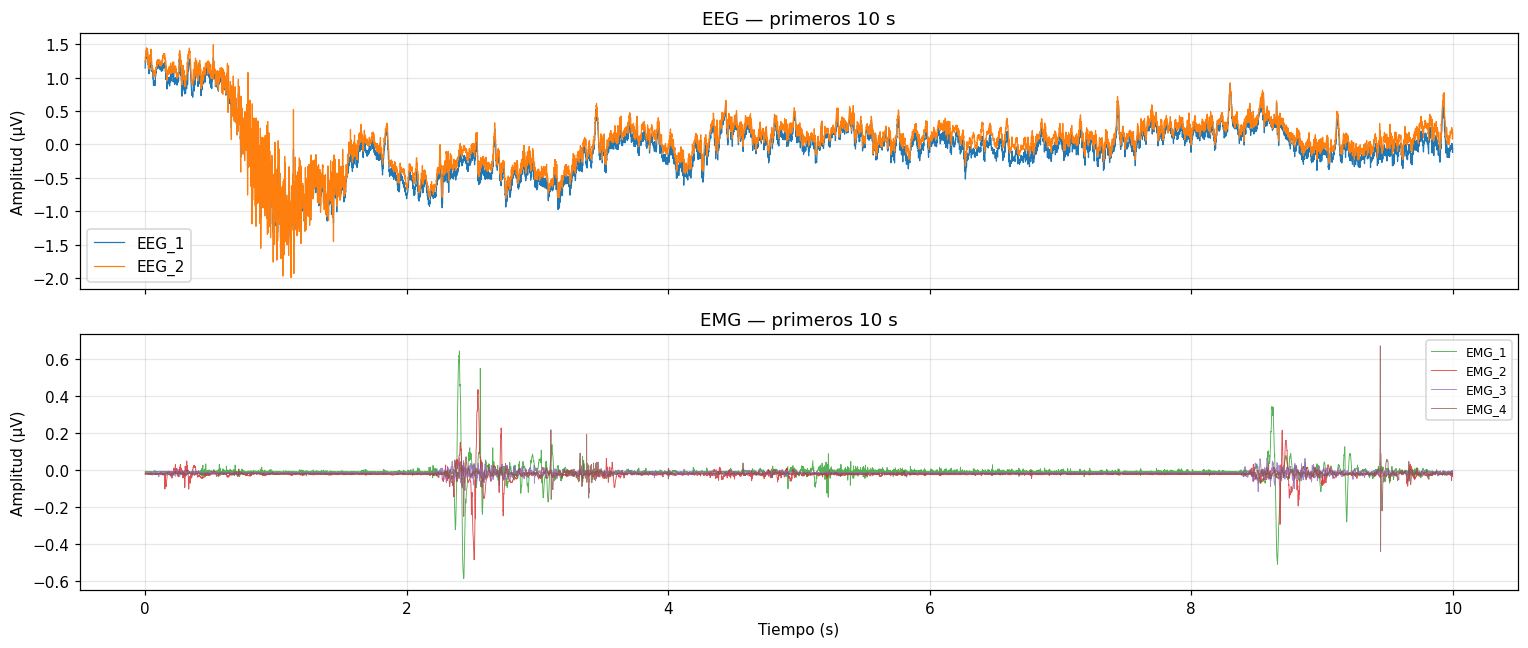

In [67]:
ZOOM_S = 10  # segundos a visualizar
n_zoom = int(ZOOM_S * SRATE)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

for i, col in enumerate(eeg_cols):
    axes[0].plot(t[:n_zoom], df[col].values[:n_zoom], label=col, lw=0.8, color=colors_eeg[i])
axes[0].set_title(f'EEG — primeros {ZOOM_S} s')
axes[0].set_ylabel('Amplitud (µV)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for j, col in enumerate(emg_cols):
    axes[1].plot(t[:n_zoom], df[col].values[:n_zoom], label=col, lw=0.6, color=colors_emg[j], alpha=0.8)
axes[1].set_title(f'EMG — primeros {ZOOM_S} s')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Amplitud (µV)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. ¿Cuál canal EMG usar como detector de bursts?

Evaluamos cuál de los 4 canales EMG tiene mayor varianza y kurtosis.

Un buen canal para burst detection tiene:
- **Alta kurtosis** → distribución con colas pesadas (eventos de alta amplitud bien definidos)
- **RMS alto relativo a la línea base** → buena relación señal/ruido
- **PSD con energía en 20–150 Hz** → banda típica del EMG muscular

In [68]:
emg_ranking = []
for col in emg_cols:
    x = df[col].values
    x_centered = x - np.mean(x)
    x_rect = np.abs(x_centered)
    
    # Energía en banda EMG (20–150 Hz)
    freqs, psd = signal.welch(x_centered, SRATE, nperseg=1024)
    mask_emg = (freqs >= 20) & (freqs <= 150)
    emg_band_power = np.trapezoid(psd[mask_emg], freqs[mask_emg])
    total_power = np.trapezoid(psd, freqs)
    emg_ratio = emg_band_power / total_power
    
    emg_ranking.append({
        'Canal'           : col,
        'RMS'             : np.sqrt(np.mean(x_centered**2)),
        'Kurtosis'        : kurtosis(x_rect),
        'Potencia_EMG_band': emg_band_power,
        'Ratio_EMG_band'  : emg_ratio,
        'Score'           : kurtosis(x_rect) * emg_ratio * 100,  # score compuesto
    })

ranking_df = pd.DataFrame(emg_ranking).set_index('Canal').sort_values('Score', ascending=False)
print('Ranking de canales EMG para detección de bursts:')
print('(mayor Score = mejor candidato)\n')
ranking_df.round(4)

Ranking de canales EMG para detección de bursts:
(mayor Score = mejor candidato)



,RMS,Kurtosis,Potencia_EMG_band,Ratio_EMG_band,Score
Canal,,,,,
EMG_4,0.0118,384.7079,0.0001,0.5240,20157.4404
EMG_3,0.0075,190.5134,0.0000,0.6918,13179.6701
EMG_1,0.0241,199.3777,0.0002,0.3674,7325.5324
EMG_2,0.0198,152.7639,0.0002,0.4058,6198.4186


Canal EMG recomendado para burst detection: EMG_4


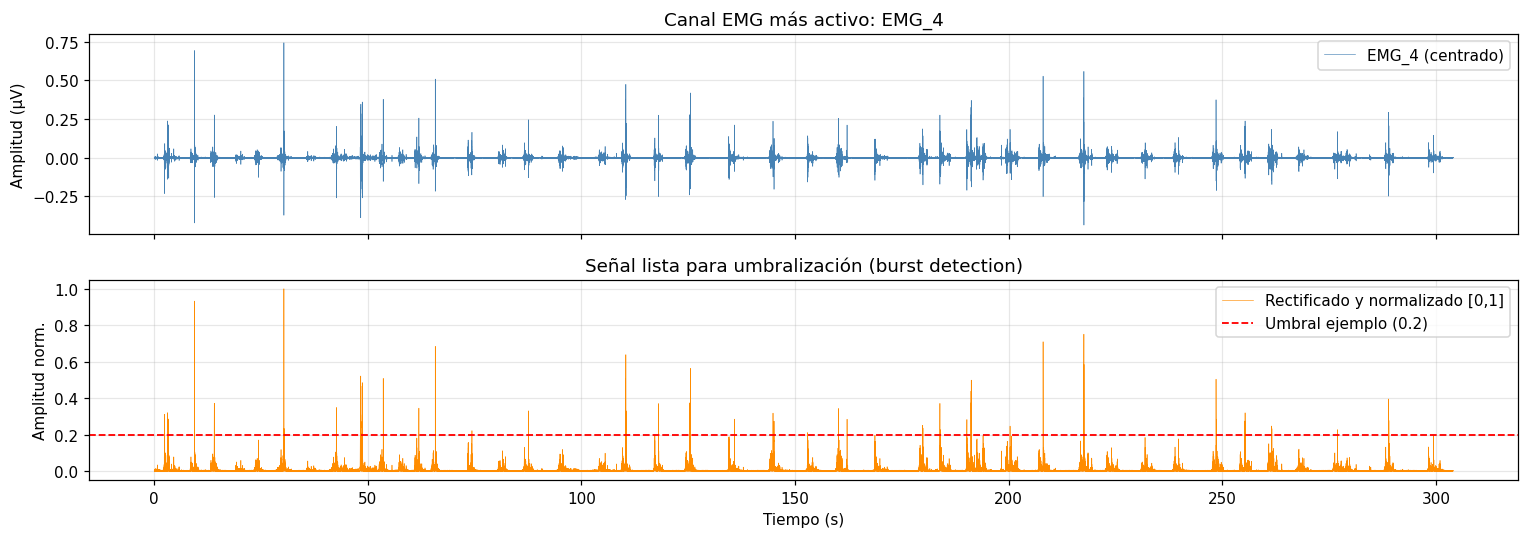

In [69]:
best_emg = ranking_df.index[0]
print(f'Canal EMG recomendado para burst detection: {best_emg}')

# Visualizar el mejor canal rectificado
x_best = df[best_emg].values
x_best = x_best - np.mean(x_best)
x_rect = np.abs(x_best)
# Normalizar entre 0 y 1 (como hace app_edu.py)
x_norm = (x_rect - x_rect.min()) / (x_rect.max() - x_rect.min())

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

axes[0].plot(t, x_best, lw=0.4, color='steelblue', label=f'{best_emg} (centrado)')
axes[0].set_title(f'Canal EMG más activo: {best_emg}')
axes[0].set_ylabel('Amplitud (µV)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, x_norm, lw=0.4, color='darkorange', label='Rectificado y normalizado [0,1]')
axes[1].axhline(0.2, color='red', lw=1.2, ls='--', label='Umbral ejemplo (0.2)')
axes[1].set_title('Señal lista para umbralización (burst detection)')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Amplitud norm.')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. EEG: verificar bandas de interés

Filtrar y visualizar la **banda Beta (13–30 Hz)** en EEG_1 y EEG_2. Esta es la banda clave para detectar **desincronización pre-movimiento** (ERDS).

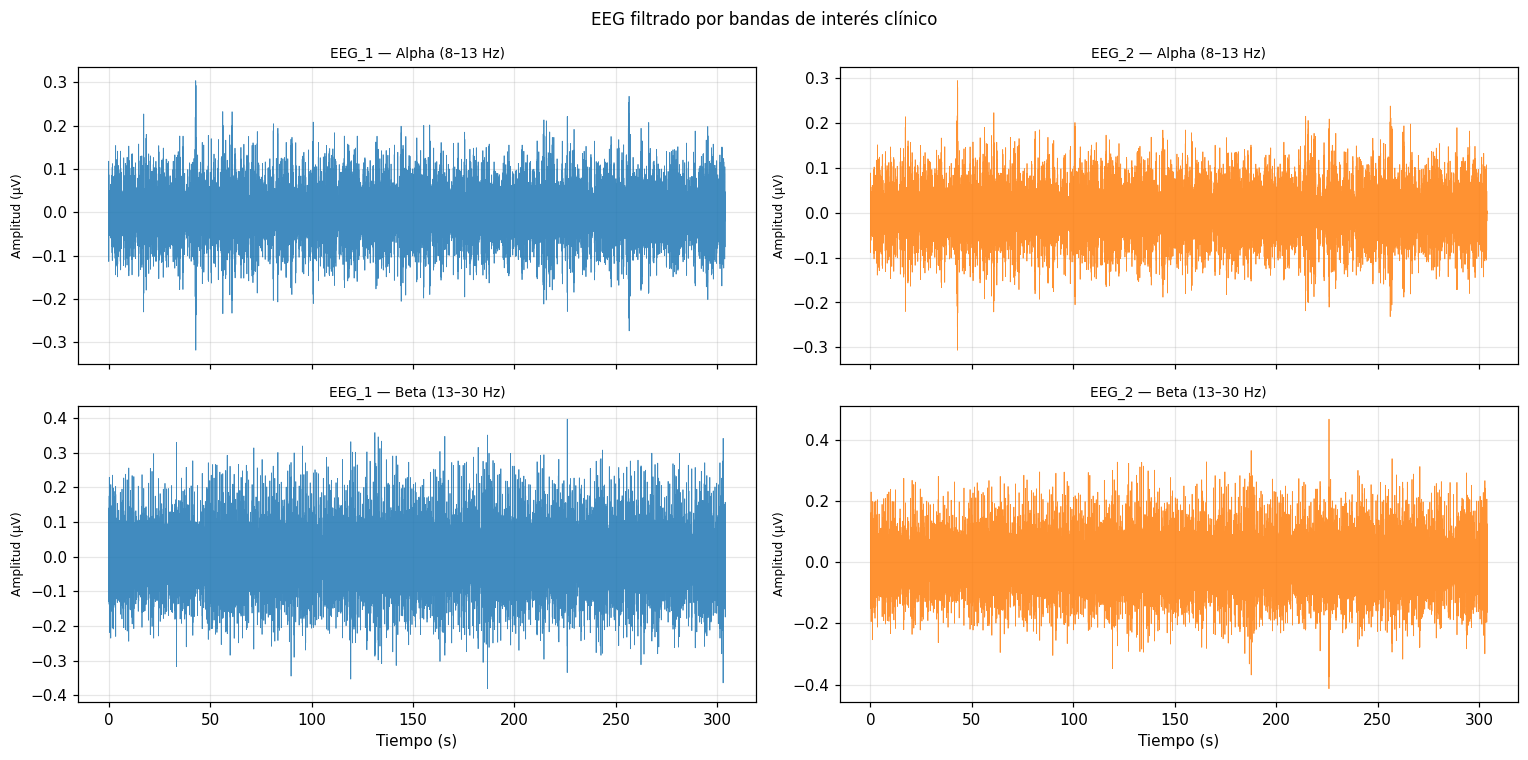

In [70]:
from scipy.signal import butter, sosfilt, sosfiltfilt

def bandpass(x, lo, hi, srate, order=4):
    nyq = srate / 2
    sos = butter(order, [lo/nyq, hi/nyq], btype='band', output='sos')
    return sosfiltfilt(sos, x)

bands = [
    ('Alpha (8–13 Hz)', 8, 13),
    ('Beta (13–30 Hz)', 13, 30),
]

# 2 EEG × 2 bandas
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)

for row, (band_name, lo, hi) in enumerate(bands):
    for col_i, eeg_col in enumerate(eeg_cols):
        x = df[eeg_col].values
        x_filt = bandpass(x, lo, hi, SRATE)
        axes[row][col_i].plot(t, x_filt, lw=0.5, color=colors_eeg[col_i], alpha=0.85)
        axes[row][col_i].set_title(f'{eeg_col} — {band_name}', fontsize=9)
        axes[row][col_i].set_ylabel('Amplitud (µV)', fontsize=8)
        axes[row][col_i].grid(True, alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel('Tiempo (s)')

plt.suptitle('EEG filtrado por bandas de interés clínico', fontsize=11)
plt.tight_layout()
plt.show()

## 8. Espectrograma EEG — vista tiempo-frecuencia

Ver si hay modulación espectral a lo largo del tiempo (indicativo de actividad cognitiva/motora).

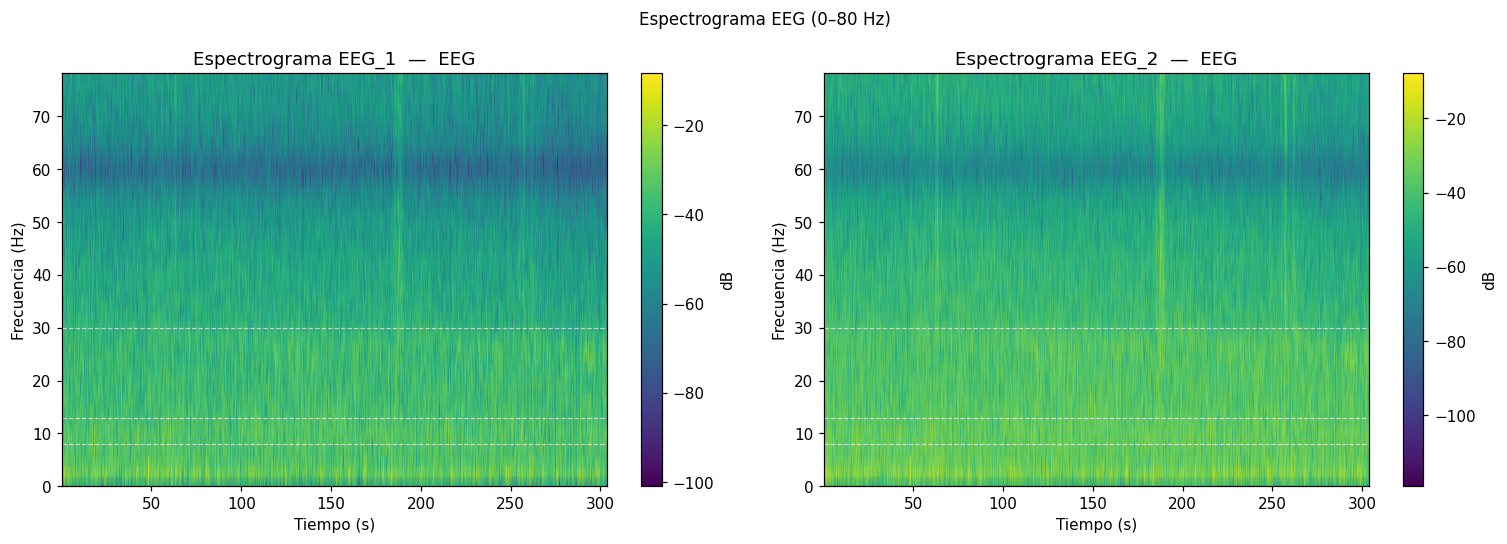

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(eeg_cols):
    x = df[col].values
    f, t_spec, Sxx = signal.spectrogram(x, SRATE, nperseg=512, noverlap=256)
    freq_mask = f <= 80
    im = axes[i].pcolormesh(t_spec, f[freq_mask], 10*np.log10(Sxx[freq_mask] + 1e-12),
                             shading='gouraud', cmap='viridis')
    axes[i].set_title(f'Espectrograma {col}  —  EEG')
    axes[i].set_xlabel('Tiempo (s)')
    axes[i].set_ylabel('Frecuencia (Hz)')
    for freq_line, label in [(8,'\u03b1'), (13,'\u03b2'), (30,'\u03b3')]:
        axes[i].axhline(freq_line, color='white', lw=0.8, ls='--', alpha=0.6)
        axes[i].text(t_spec[-1]*1.01, freq_line, label, color='white', fontsize=8, va='center')
    plt.colorbar(im, ax=axes[i], label='dB')

plt.suptitle('Espectrograma EEG (0–80 Hz)', fontsize=11)
plt.tight_layout()
plt.show()

## 9. Resumen y recomendaciones

Basado en el análisis anterior:

In [72]:
print('=' * 55)
print('RESUMEN DE EXPLORACIÓN')
print('=' * 55)
print(f'Duración total   : {df.Tiempo_s.iloc[-1]:.0f} s  ({df.Tiempo_s.iloc[-1]/60:.1f} min)')
print(f'Tasa de muestreo : {SRATE} Hz')
print(f'Muestras         : {len(df):,}')
print()
print('Canales EEG:')
for col in eeg_cols:
    print(f'  {col}: rango [{df[col].min():.3f}, {df[col].max():.3f}]')
print()
print('Canales EMG:')
for col in emg_cols:
    print(f'  {col}: rms={np.sqrt(np.mean(df[col].values**2)):.5f}  '
          f'rango [{df[col].min():.4f}, {df[col].max():.4f}]')
print()
print('Canal EMG recomendado para burst detection:')
print(f'  → {best_emg}  (mayor kurtosis y energía en banda 20–150 Hz)')
print()
print('Próximos pasos:')
print('  1. Aplicar filtros (highpass 1 Hz, lowpass 100 Hz, notch 50 Hz)')
print('  2. Comparar BacAV vs clustering espectral (Sección 10)')
print('  3. Usar bursts como marcadores → segmentar EEG')
print('  4. Calcular ERP y ERDS (desincronización beta pre-movimiento)')
print('=' * 55)

RESUMEN DE EXPLORACIÓN
Duración total   : 304 s  (5.1 min)
Tasa de muestreo : 1000 Hz
Muestras         : 304,011

Canales EEG:
  EEG_1: rango [-1.587, 1.618]
  EEG_2: rango [-1.988, 2.673]

Canales EMG:
  EMG_1: rms=0.02680  rango [-0.6875, 0.8581]
  EMG_2: rms=0.03103  rango [-0.8919, 0.5395]
  EMG_3: rms=0.01773  rango [-0.2200, 0.5102]
  EMG_4: rms=0.02437  rango [-0.4557, 0.7209]

Canal EMG recomendado para burst detection:
  → EMG_4  (mayor kurtosis y energía en banda 20–150 Hz)

Próximos pasos:
  1. Aplicar filtros (highpass 1 Hz, lowpass 100 Hz, notch 50 Hz)
  2. Comparar BacAV vs clustering espectral (Sección 10)
  3. Usar bursts como marcadores → segmentar EEG
  4. Calcular ERP y ERDS (desincronización beta pre-movimiento)


## 10. Comparación: detección de bursts EMG — BacAV vs Clustering Espectral

Comparamos dos enfoques para detectar el **onset de bursts musculares** en el canal EMG óptimo:

| Método | Principio |
|--------|-----------|
| **BacAV** (Vial et al., 2020) | Umbralización sobre señal rectificada y normalizada [0,1]; verifica amplitud media en ventana pre/post candidato |
| **K-Means espectral** | Extrae features por ventana corta (RMS + potencia 20–150 Hz) y agrupa en `burst` vs `reposo` |

La congruencia entre ambos valida que los eventos detectados corresponden a activaciones musculares reales.

### Celda 1 — Selección del canal EMG y detección de bursts con BacAV

Antes de comparar métodos, necesitamos elegir **con qué canal EMG trabajar** y **detectar los bursts**.

**Canal EMG:** usamos `best_emg`, el canal que obtuvo mayor score en la sección 6 (mayor kurtosis + mayor proporción de energía en 20–150 Hz). Ese canal es el que mejor representa la activación muscular.

**Algoritmo BacAV** (Vial et al., 2020):
El método opera en 4 pasos sobre la señal cruda:
1. **Centrar** la señal (restar la media) para eliminar offset DC
2. **Rectificar** (valor absoluto) — convierte picos positivos y negativos en una envolvente de amplitud
3. **Normalizar a [0,1]** — hace el umbral independiente de la ganancia del amplificador
4. **Umbralizar + verificar ventana pre/post** — un candidato a burst debe superar el umbral *y* tener baja amplitud antes y alta amplitud después, evitando falsos positivos por ruido puntual

El resultado es `bursts_bacav`: array con los índices de muestra del **onset** de cada burst.

In [103]:
# ── 1. Canal EMG seleccionado ─────────────────────────────────────────────────
EMG_CH  = best_emg
emg_raw = df[EMG_CH].values
t       = df['Tiempo_s'].values
print(f'Canal EMG seleccionado: {EMG_CH}')

# ── 2. Método BacAV ───────────────────────────────────────────────────────────
# Reproducción del algoritmo descrito en Vial et al. (2020):
# rectificar → normalizar [0,1] → umbralizar → verificar ventana pre/post

def detect_bursts_bacav(
    x, srate,
    threshold=0.10,
    time_before=0.1,
    time_after=0.10,
    amp_before=0.1,
    amp_after=0.05,
    burst_duration=0.3
):
    x_c    = x - np.mean(x)
    x_rect = np.abs(x_c)
    x_norm = (x_rect - x_rect.min()) / (x_rect.max() - x_rect.min())
    n_before = int(time_before * srate)
    n_after  = int(time_after  * srate)
    n_gap    = int(burst_duration * srate)
    bursts, last = [], -n_gap
    for idx in np.where(x_norm > threshold)[0]:
        if idx - last < n_gap:
            continue
        if idx < n_before or idx + n_after >= len(x_norm):
            continue
        if (np.mean(x_norm[idx - n_before:idx]) < amp_before and
                np.mean(x_norm[idx:idx + n_after]) > amp_after):
            bursts.append(idx)
            last = idx
    return np.array(bursts)

bursts_bacav = detect_bursts_bacav(emg_raw, SRATE)
print(f'BacAV   → {len(bursts_bacav):4d} bursts')

Canal EMG seleccionado: EMG_4
BacAV   →   30 bursts


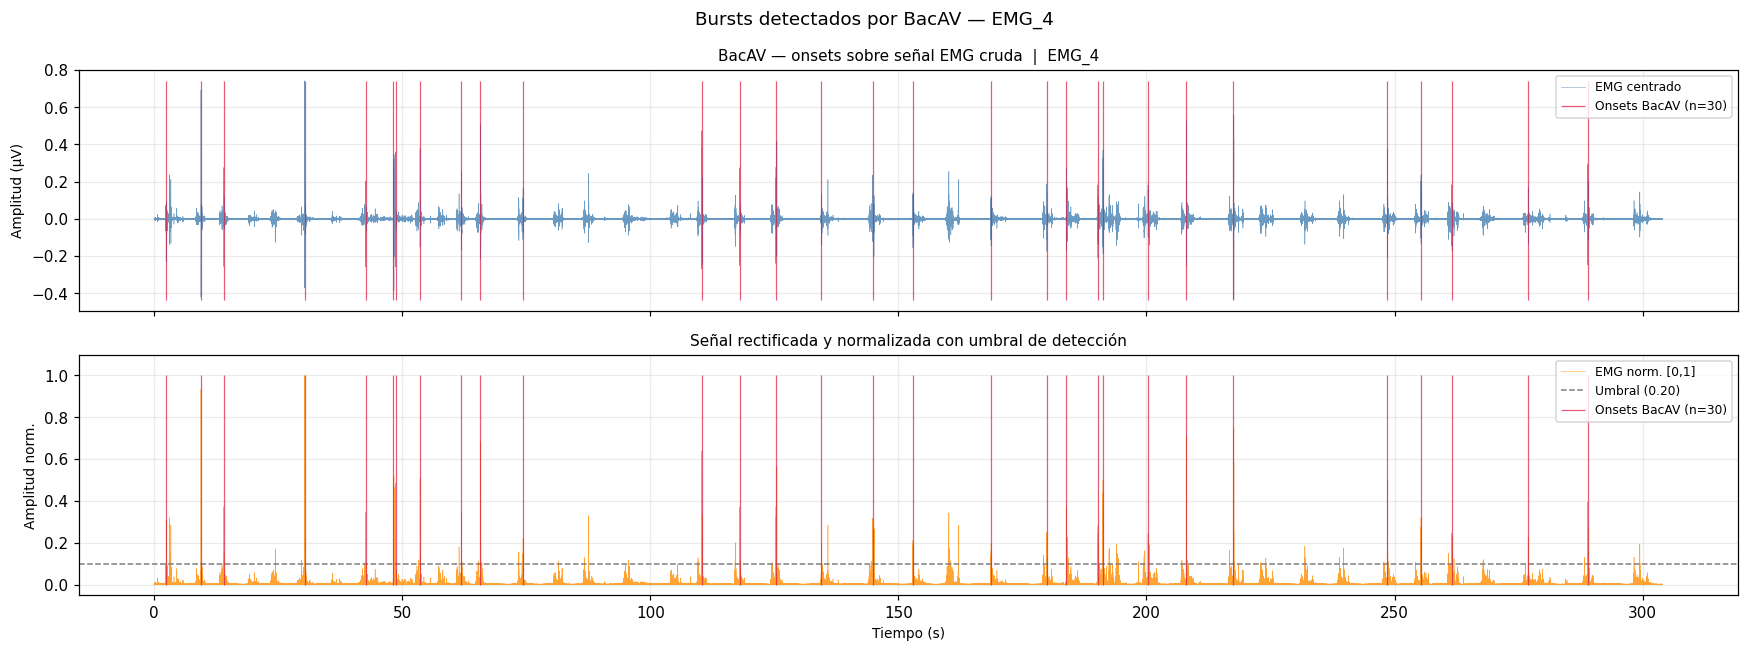

Total bursts BacAV : 30
Tasa media         : 5.9 bursts/min
Intervalo medio    : 9.88 s  ± 7.49 s


In [104]:
x_c_bv    = emg_raw - np.mean(emg_raw)
x_rect_bv = np.abs(x_c_bv)
x_norm_bv = (x_rect_bv - x_rect_bv.min()) / (x_rect_bv.max() - x_rect_bv.min())

fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

# ── Panel superior: señal cruda con marcadores ────────────────────────────────
axes[0].plot(t, x_c_bv, lw=0.35, color='steelblue', alpha=0.8, label='EMG centrado')
axes[0].vlines(t[bursts_bacav], x_c_bv.min(), x_c_bv.max(),
               color='crimson', lw=0.8, alpha=0.7, label=f'Onsets BacAV (n={len(bursts_bacav)})')
axes[0].set_title(f'BacAV — onsets sobre señal EMG cruda  |  {EMG_CH}', fontsize=10)
axes[0].set_ylabel('Amplitud (µV)', fontsize=9)
axes[0].legend(fontsize=8, loc='upper right')
axes[0].grid(True, alpha=0.25)

# ── Panel inferior: señal normalizada con umbral ──────────────────────────────
axes[1].plot(t, x_norm_bv, lw=0.35, color='darkorange', alpha=0.8, label='EMG norm. [0,1]')
axes[1].axhline(0.1, color='gray', lw=1, ls='--', label='Umbral (0.20)')
axes[1].vlines(t[bursts_bacav], 0, 1,
               color='crimson', lw=0.8, alpha=0.7, label=f'Onsets BacAV (n={len(bursts_bacav)})')
axes[1].set_title('Señal rectificada y normalizada con umbral de detección', fontsize=10)
axes[1].set_xlabel('Tiempo (s)', fontsize=9)
axes[1].set_ylabel('Amplitud norm.', fontsize=9)
axes[1].set_ylim(-0.05, 1.1)
axes[1].legend(fontsize=8, loc='upper right')
axes[1].grid(True, alpha=0.25)

plt.suptitle(f'Bursts detectados por BacAV — {EMG_CH}', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Total bursts BacAV : {len(bursts_bacav)}')
print(f'Tasa media         : {len(bursts_bacav) / t[-1] * 60:.1f} bursts/min')
print(f'Intervalo medio    : {np.mean(np.diff(t[bursts_bacav])):.2f} s  '
      f'± {np.std(np.diff(t[bursts_bacav])):.2f} s')

Bursts detectados: 30
Mostrando burst #0  (t = 2.37 s)


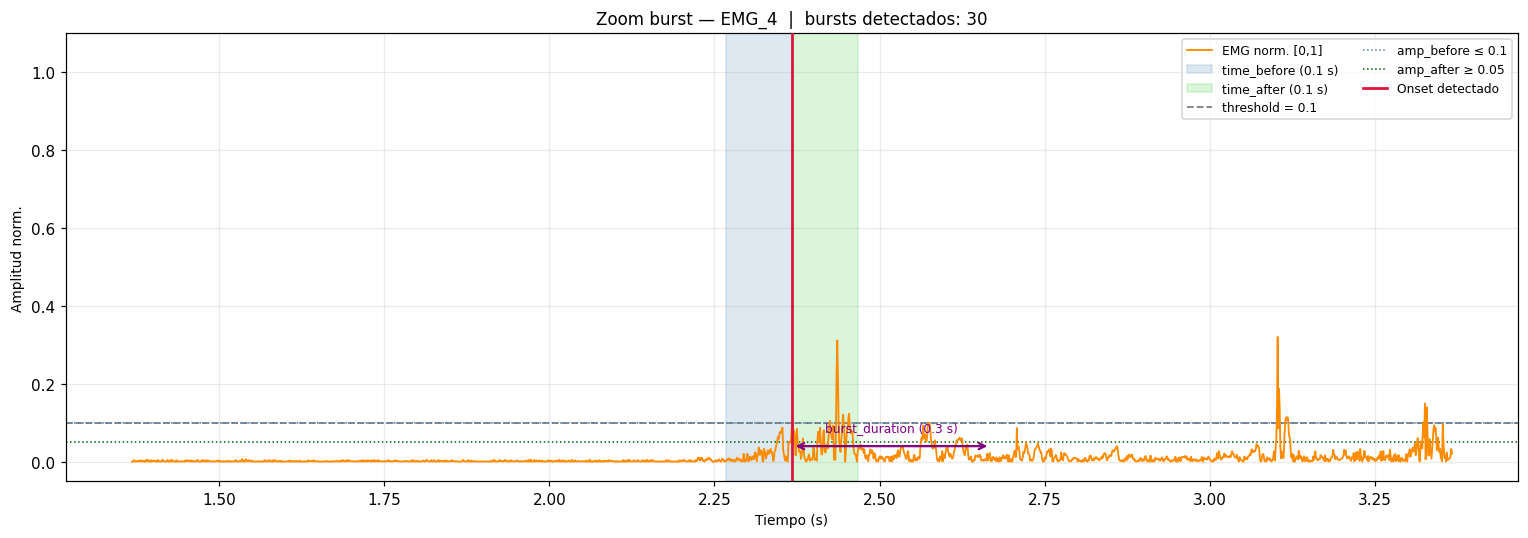

In [100]:
# ── Parámetros editables ──────────────────────────────────────────────────────

THRESHOLD      = 0.10   # nivel mínimo sobre señal norm. [0,1]
TIME_BEFORE    = 0.10   # ventana pre-onset (s)
TIME_AFTER     = 0.10   # ventana post-onset (s)
AMP_BEFORE     = 0.10   # media en ventana pre-onset debe ser < este valor
AMP_AFTER      = 0.05   # media en ventana post-onset debe ser > este valor
BURST_DURATION = 0.3   # gap mínimo entre bursts consecutivos (s)
MARGIN_S       = 1.0    # margen de zoom a cada lado del burst (s)

# Re-detectar con los parámetros actuales
bursts_bacav = detect_bursts_bacav(
    emg_raw, SRATE,
    threshold=THRESHOLD, time_before=TIME_BEFORE, time_after=TIME_AFTER,
    amp_before=AMP_BEFORE, amp_after=AMP_AFTER, burst_duration=BURST_DURATION,
)
print(f'Bursts detectados: {len(bursts_bacav)}')

# Elegir el burst a visualizar (índice 0 = primero; cambia si quieres otro)
if len(bursts_bacav) > 0:
    center_idx = bursts_bacav[0]
    print(f'Mostrando burst #0  (t = {t[center_idx]:.2f} s)')
else:
    center_idx = int(np.argmax(x_norm_bv))
    print(f'⚠ Sin bursts detectados — mostrando pico máximo (t = {t[center_idx]:.2f} s)')

# ── Ventana de zoom ───────────────────────────────────────────────────────────
n_margin  = int(MARGIN_S * SRATE)
s_zoom    = max(0, center_idx - n_margin)
e_zoom    = min(len(emg_raw), center_idx + n_margin)
t_zoom    = t[s_zoom:e_zoom]
sig_zoom  = x_norm_bv[s_zoom:e_zoom]
local_idx = center_idx - s_zoom

n_bef = int(TIME_BEFORE * SRATE)
n_aft = int(TIME_AFTER  * SRATE)
t_onset      = t_zoom[local_idx]
t_bef_start  = t_zoom[max(0, local_idx - n_bef)]
t_aft_end    = t_zoom[min(len(t_zoom) - 1, local_idx + n_aft)]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(t_zoom, sig_zoom, lw=1.2, color='darkorange', zorder=3, label='EMG norm. [0,1]')

# Zonas pre/post onset
ax.axvspan(t_bef_start, t_onset,   alpha=0.18, color='steelblue',
           label=f'time_before ({TIME_BEFORE} s)')
ax.axvspan(t_onset,     t_aft_end, alpha=0.18, color='limegreen',
           label=f'time_after ({TIME_AFTER} s)')

# Líneas de parámetros
ax.axhline(THRESHOLD,  color='gray',       lw=1.2, ls='--', label=f'threshold = {THRESHOLD}')
ax.axhline(AMP_BEFORE, color='steelblue',  lw=1.0, ls=':',  label=f'amp_before ≤ {AMP_BEFORE}')
ax.axhline(AMP_AFTER,  color='darkgreen',  lw=1.0, ls=':',  label=f'amp_after ≥ {AMP_AFTER}')

# Onset
ax.axvline(t_onset, color='crimson', lw=1.8, zorder=4, label='Onset detectado')

# Flecha burst_duration
y_arrow = 0.04
ax.annotate('', xy=(t_onset + BURST_DURATION, y_arrow), xytext=(t_onset, y_arrow),
            arrowprops=dict(arrowstyle='<->', color='purple', lw=1.5))
ax.text(t_onset + BURST_DURATION / 2, y_arrow + 0.04,
        f'burst_duration ({BURST_DURATION} s)', ha='center', fontsize=8, color='purple')

ax.set_title(f'Zoom burst — {EMG_CH}  |  bursts detectados: {len(bursts_bacav)}', fontsize=11)
ax.set_xlabel('Tiempo (s)', fontsize=9)
ax.set_ylabel('Amplitud norm.', fontsize=9)
ax.set_ylim(-0.05, 1.1)
ax.legend(fontsize=8, loc='upper right', ncol=2)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

### Ajuste de parámetros BacAV — zoom en un burst

La celda siguiente muestra un zoom de **±1 segundo alrededor del primer burst** con todos los parámetros del algoritmo dibujados directamente sobre la señal.

| Parámetro | Qué controla |
|---|---|
| `THRESHOLD` | Nivel mínimo que debe superar la señal normalizada para ser candidato. Bajar este valor → más candidatos. |
| `TIME_BEFORE` | Ventana (s) que se mira *antes* del candidato para verificar que estaba en reposo. |
| `TIME_AFTER` | Ventana (s) que se mira *después* del candidato para verificar que hay actividad sostenida. |
| `AMP_BEFORE` | La media en la ventana pre-onset debe ser **menor** que este valor (confirma reposo previo). |
| `AMP_AFTER` | La media en la ventana post-onset debe ser **mayor** que este valor (confirma activación real). |
| `BURST_DURATION` | Gap mínimo entre dos bursts consecutivos. Dos detecciones más cercanas que esto se fusionan en una. |

**Cómo usar:** edita los valores en la celda de abajo y re-ejecútala. El título del plot y el print muestran cuántos bursts quedan con esos parámetros. Una vez satisfecho, copia los valores a la función `detect_bursts_bacav` de la Celda 1.

### Celda 3 — Visualización interna del K-Means (3 paneles)

Esta figura muestra **cómo quedaron los clusters del K-Means**, no los bursts en sí. Tiene 3 paneles:

**Panel A — Espacio de features (scatter)**
Cada punto es una ventana de 50 ms. El eje X es su RMS, el eje Y es su potencia en 20–150 Hz. El K-Means separó estas ventanas en 2 grupos (verde = burst, rojo = reposo). Si los clusters están bien separados, significa que la distinción burst/reposo es clara en los datos.

**Panel B — Boxplot de RMS por cluster**
Confirma que el cluster "burst" tiene RMS significativamente mayor que el de "reposo". Si las cajas se solapan mucho, la separación es ambigua.

**Panel C — Línea temporal completa**
Muestra toda la grabación con las **zonas clasificadas como burst sombreadas en verde**. Aquí se reconstruye la etiqueta de cada muestra a partir de la etiqueta de su ventana más cercana (paso = 10 ms), lo que preserva la resolución temporal real del K-Means. El título indica cuántos segundos totales fueron clasificados como burst vs. reposo.

In [76]:
from sklearn.cluster      import KMeans
from sklearn.preprocessing import StandardScaler

# ── 3. Método K-Means espectral ───────────────────────────────────────────────
WIN_S = 0.050
HOP_S = 0.010
n_win = int(WIN_S * SRATE)
n_hop = int(HOP_S * SRATE)

x_c    = emg_raw - np.mean(emg_raw)
x_rect = np.abs(x_c)

feat_list, time_list = [], []
for start in range(0, len(x_c) - n_win, n_hop):
    seg      = x_c[start:start + n_win]
    rms      = float(np.sqrt(np.mean(np.abs(seg)**2)))
    fw, pw   = signal.welch(seg, SRATE, nperseg=n_win)
    m        = (fw >= 20) & (fw <= 150)
    band_pow = float(np.trapezoid(pw[m], fw[m])) if m.sum() > 1 else 0.0
    feat_list.append([rms, band_pow])
    time_list.append((start + n_win // 2) / SRATE)

feat_arr = np.array(feat_list)
time_arr = np.array(time_list)

feat_sc       = StandardScaler().fit_transform(feat_arr)
labels_km     = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(feat_sc)
burst_cluster = int(np.argmax([feat_arr[labels_km == i, 0].mean() for i in range(2)]))
burst_mask_km = labels_km == burst_cluster

transitions   = np.where(np.diff(burst_mask_km.astype(int)) == 1)[0]
bursts_kmeans = (time_arr[transitions] * SRATE).astype(int)
print(f'K-Means → {len(bursts_kmeans):4d} bursts')
print(f'Diferencia: {abs(len(bursts_bacav) - len(bursts_kmeans))} bursts')

K-Means →   43 bursts
Diferencia: 41 bursts


### 10.1 Visualización de grupos K-Means (espacio de features + línea temporal)

**Ventaneo deslizante con solapamiento**

El RMS y la potencia de banda se calculan en **cada ventana**, avanzando de a un hop:

```
Ventana 1:  |←── 50 ms ──→|
Ventana 2:       |←── 50 ms ──→|
                 ↑
               10 ms de avance
```

Con ventana de 50 ms y paso de 10 ms, cada ventana comparte **40 ms (80%)** con la anterior. Esto es intencional: si el paso fuera igual a la ventana (sin solapamiento), los features cambiarían de golpe cada 50 ms y la clasificación K-Means sería mucho más ruidosa. El solapamiento suaviza la transición entre ventanas y da mejor resolución temporal.

In [ ]:
# ── Visualización de grupos K-Means ──────────────────────────────────────────
PALETTE = {burst_cluster: '#2ca02c', 1 - burst_cluster: '#d62728'}
LABELS  = {burst_cluster: 'Burst', 1 - burst_cluster: 'Reposo'}

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.32)

# ── Panel A: espacio de features ─────────────────────────────────────────────
ax_feat = fig.add_subplot(gs[0, 0])
for cl in [0, 1]:
    mask = labels_km == cl
    ax_feat.scatter(feat_arr[mask, 0], feat_arr[mask, 1],
                    s=4, alpha=0.35, color=PALETTE[cl],
                    label=f'{LABELS[cl]}  (n={mask.sum():,})', rasterized=True)
centers_orig = np.array([feat_arr[labels_km == cl].mean(axis=0) for cl in range(2)])
ax_feat.scatter(centers_orig[:, 0], centers_orig[:, 1],
                s=140, marker='*', color='black', zorder=5, label='Centroide')
ax_feat.set_xlabel('RMS por ventana', fontsize=9)
ax_feat.set_ylabel('Potencia 20–150 Hz', fontsize=9)
ax_feat.set_title('A — Espacio de features\n(ventanas 50 ms, paso 10 ms)', fontsize=9)
ax_feat.legend(fontsize=8)
ax_feat.grid(True, alpha=0.25)

# ── Panel B: boxplot de RMS ───────────────────────────────────────────────────
ax_box = fig.add_subplot(gs[0, 1])
data_box = [feat_arr[labels_km == cl, 0] for cl in range(2)]
bp = ax_box.boxplot(data_box, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', lw=2))
for patch, cl in zip(bp['boxes'], range(2)):
    patch.set_facecolor(PALETTE[cl])
    patch.set_alpha(0.75)
ax_box.set_xticklabels([LABELS[cl] for cl in range(2)], fontsize=9)
ax_box.set_ylabel('RMS por ventana', fontsize=9)
ax_box.set_title('B — Distribución de RMS\npor cluster K-Means', fontsize=9)
ax_box.grid(True, alpha=0.25, axis='y')

# ── Panel C: línea temporal completa ─────────────────────────────────────────
ax_time = fig.add_subplot(gs[1, :])

n_total    = len(emg_raw)
n_hop_half = n_hop // 2
color_line = np.full(n_total, 1 - burst_cluster, dtype=int)
for i, ts in enumerate(time_arr):
    idx = int(ts * SRATE)
    s = max(0, idx - n_hop_half)
    e = min(n_total, idx + n_hop_half)
    color_line[s:e] = labels_km[i]

in_burst = color_line == burst_cluster
transitions_c = np.diff(in_burst.astype(int))
starts = np.where(transitions_c ==  1)[0]
ends   = np.where(transitions_c == -1)[0]
if in_burst[0]:
    starts = np.concatenate([[0], starts])
if in_burst[-1]:
    ends = np.concatenate([ends, [n_total - 1]])

x_norm2 = np.abs(emg_raw - emg_raw.mean())
x_norm2 = (x_norm2 - x_norm2.min()) / (x_norm2.max() - x_norm2.min())

# Zonas burst sombreadas
for s, e in zip(starts, ends):
    ax_time.axvspan(t[s], t[e], alpha=0.25, color='#2ca02c', lw=0)

# Señal
ax_time.plot(t, x_norm2, lw=0.35, color='steelblue', alpha=0.8)

# Onsets como líneas verticales (visibles a cualquier escala)
ax_time.vlines(t[bursts_kmeans], 0, 1,
               color='darkgreen', lw=0.8, alpha=0.7,
               label=f'Onsets K-Means (n={len(bursts_kmeans)})')

ax_time.set_xlabel('Tiempo (s)', fontsize=9)
ax_time.set_ylabel('Amplitud norm.', fontsize=9)
burst_s  = int(in_burst.sum() / SRATE)
reposo_s = int((~in_burst).sum() / SRATE)
ax_time.set_title(
    f'C — Clasificación temporal K-Means  '
    f'({len(bursts_kmeans)} bursts  |  {burst_s} s en burst  /  {reposo_s} s en reposo)',
    fontsize=9)
ax_time.grid(True, alpha=0.20)

from matplotlib.patches import Patch
ax_time.legend(handles=[
    Patch(facecolor='#2ca02c', alpha=0.45, label='Zona burst'),
    Patch(facecolor='steelblue', alpha=0.45, label='EMG norm.'),
    plt.Line2D([0], [0], color='darkgreen', lw=0.8, label=f'Onsets (n={len(bursts_kmeans)})'),
], fontsize=8, loc='upper right')

plt.suptitle(f'Grupos K-Means — {EMG_CH}  (k=2, burst vs reposo)', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Ventanas totales : {len(labels_km):,}')
print(f'  Burst          : {(labels_km == burst_cluster).sum():,}  '
      f'({(labels_km == burst_cluster).mean()*100:.1f} %)')
print(f'  Reposo         : {(labels_km != burst_cluster).sum():,}  '
      f'({(labels_km != burst_cluster).mean()*100:.1f} %)')
print(f'  Episodios burst: {len(starts):,}')


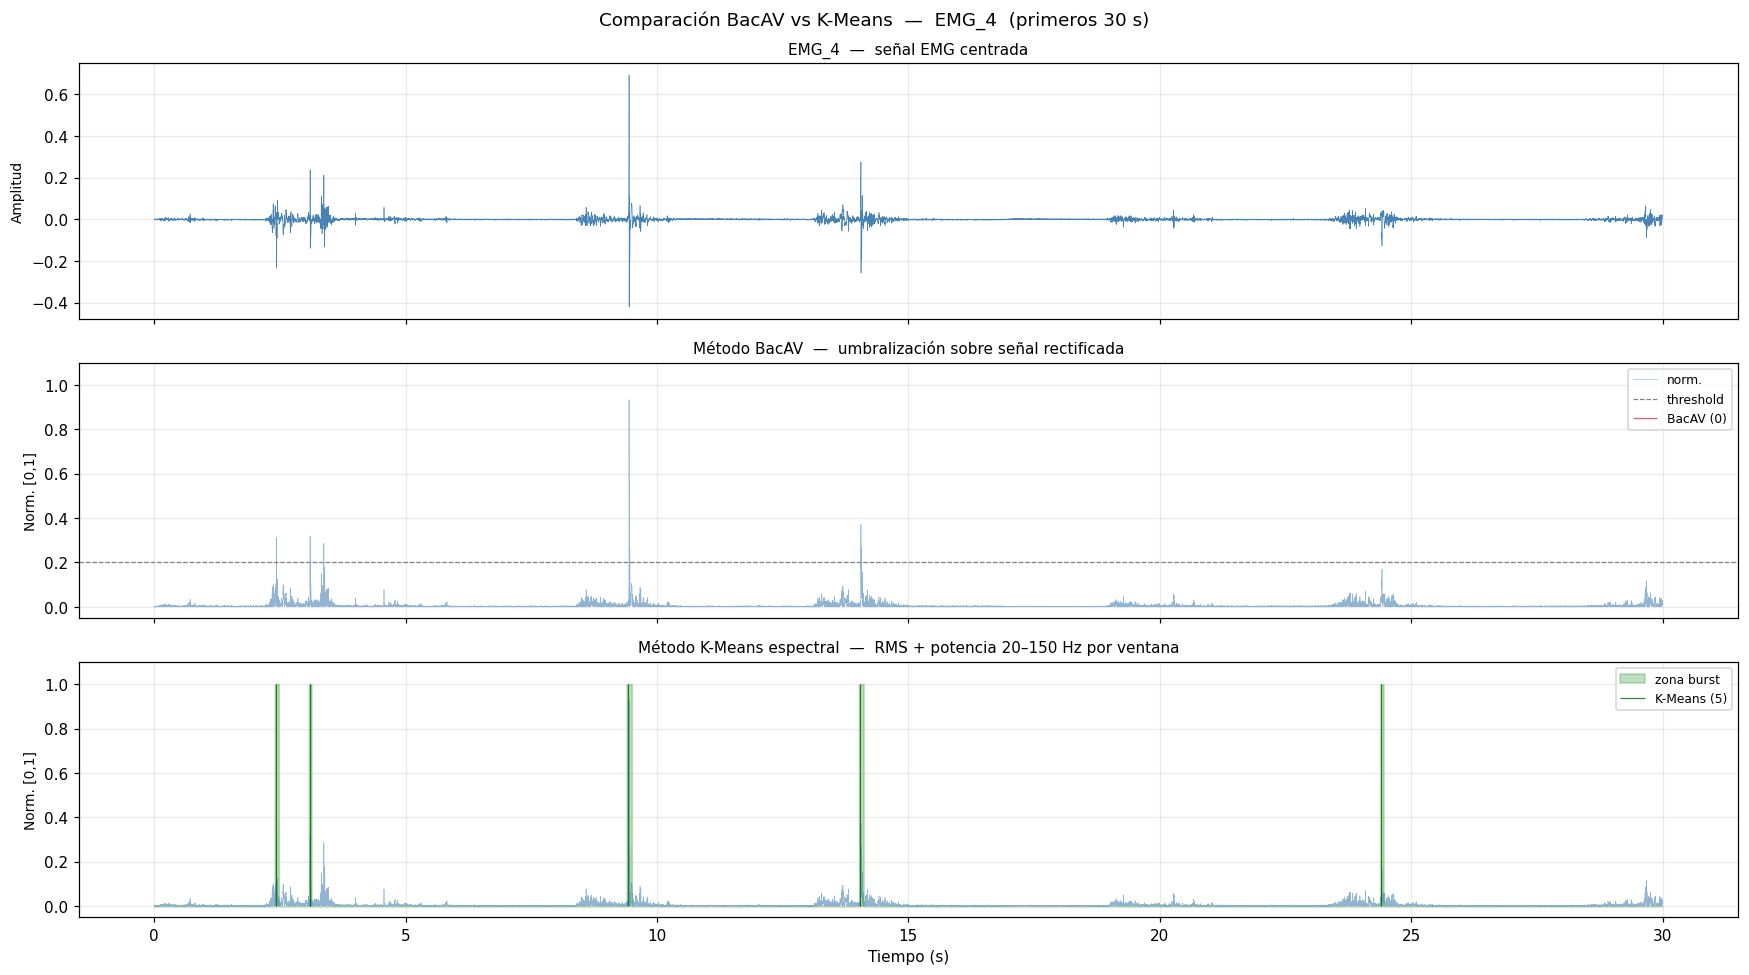

In [78]:
# ── 4. Visualización comparativa (primeros 30 s) ──────────────────────────────
SHOW_S   = 30
n_show   = int(SHOW_S * SRATE)

x_c_full    = emg_raw - np.mean(emg_raw)
x_rect_full = np.abs(x_c_full)
x_norm_full = (x_rect_full - x_rect_full.min()) / (x_rect_full.max() - x_rect_full.min())

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

axes[0].plot(t[:n_show], x_c_full[:n_show], lw=0.4, color='steelblue')
axes[0].set_title(f'{EMG_CH}  —  señal EMG centrada', fontsize=10)
axes[0].set_ylabel('Amplitud', fontsize=9)
axes[0].grid(True, alpha=0.25)

bv_show = bursts_bacav[bursts_bacav < n_show]
axes[1].plot(t[:n_show], x_norm_full[:n_show], lw=0.4, color='steelblue', alpha=0.6, label='norm.')
axes[1].axhline(0.20, color='gray', lw=0.8, ls='--', label='threshold')
axes[1].vlines(t[bv_show], 0, 1, color='crimson', lw=0.8, alpha=0.7, label=f'BacAV ({len(bv_show)})')
axes[1].set_title('Método BacAV  —  umbralización sobre señal rectificada', fontsize=10)
axes[1].set_ylabel('Norm. [0,1]', fontsize=9)
axes[1].legend(fontsize=8, loc='upper right')
axes[1].grid(True, alpha=0.25)
axes[1].set_ylim(-0.05, 1.1)

burst_signal = np.zeros(n_show)
for i, ts in enumerate(time_arr):
    idx = int(ts * SRATE)
    if idx >= n_show:
        break
    s = max(0, idx - n_win // 2)
    e = min(n_show, idx + n_win // 2)
    if burst_mask_km[i]:
        burst_signal[s:e] = 1

km_show = bursts_kmeans[bursts_kmeans < n_show]
axes[2].fill_between(t[:n_show], 0, burst_signal, alpha=0.25, color='green', label='zona burst')
axes[2].plot(t[:n_show], x_norm_full[:n_show], lw=0.4, color='steelblue', alpha=0.6)
axes[2].vlines(t[km_show], 0, 1, color='darkgreen', lw=0.8, alpha=0.8, label=f'K-Means ({len(km_show)})')
axes[2].set_title('Método K-Means espectral  —  RMS + potencia 20–150 Hz por ventana', fontsize=10)
axes[2].set_xlabel('Tiempo (s)')
axes[2].set_ylabel('Norm. [0,1]', fontsize=9)
axes[2].legend(fontsize=8, loc='upper right')
axes[2].grid(True, alpha=0.25)
axes[2].set_ylim(-0.05, 1.1)

plt.suptitle(f'Comparación BacAV vs K-Means  —  {EMG_CH}  (primeros {SHOW_S} s)', fontsize=12)
plt.tight_layout()
plt.show()

### Celda 4 — Comparación visual BacAV vs K-Means (primeros 30 s)

Esta figura compara directamente los dos métodos sobre la **misma ventana temporal de 30 segundos**, con 3 paneles apilados que comparten el eje X:

**Panel 1 — Señal EMG cruda (centrada)**
La señal tal como viene del amplificador, solo con la media restada. Sirve como referencia visual para ver cuándo hay actividad muscular real.

**Panel 2 — Método BacAV**
- La señal rectificada y normalizada [0,1] (la misma que procesa el algoritmo)
- La línea discontinua gris es el umbral (0.20)
- Cada **línea vertical roja** es un onset de burst detectado por BacAV
- La leyenda muestra cuántos bursts caen dentro de estos 30 s

**Panel 3 — Método K-Means**
- El **área verde sombreada** son las zonas que K-Means clasificó como "burst" en estos 30 s
- Cada **línea vertical verde oscuro** es el onset de un episodio burst según K-Means
- La leyenda muestra cuántos onsets caen dentro de estos 30 s

**Qué buscar:** que las líneas rojas (BacAV) y verdes (K-Means) aparezcan en los mismos momentos, y que ambas coincidan con los picos visibles en el panel 1. Si hay buena concordancia, ambos métodos están detectando las mismas activaciones musculares.

Tolerancia: ±200 ms
Bursts BacAV  con match K-Means :    2/2  (100.0%)
Bursts K-Means con match BacAV  :    2/43  (4.7%)


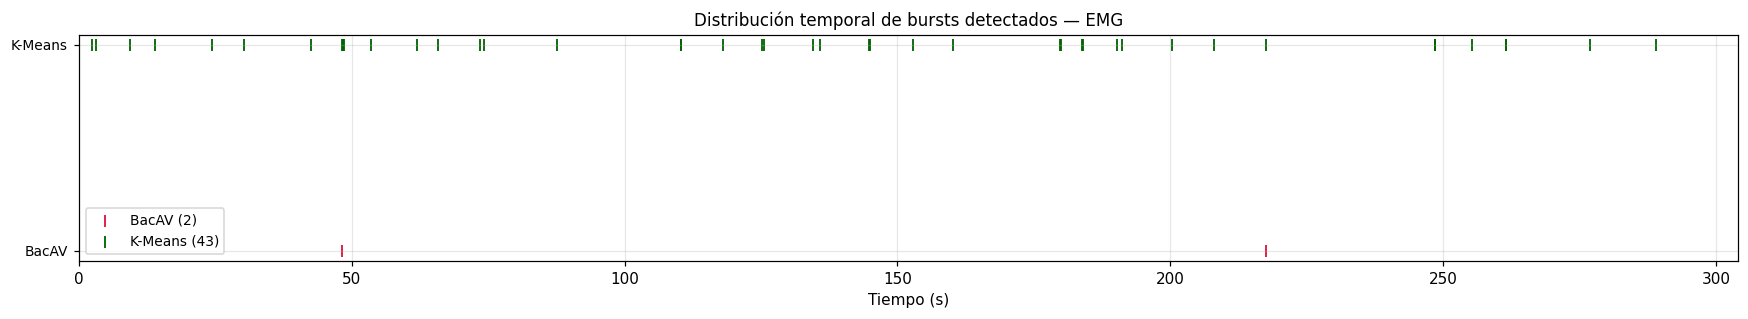

In [79]:
# ── 5. Concordancia cuantitativa (±200 ms) ────────────────────────────────────
TOL_S = 0.200

matched_bv = sum(
    1 for b in bursts_bacav if np.any(np.abs(bursts_kmeans - b) / SRATE <= TOL_S)
)
matched_km = sum(
    1 for b in bursts_kmeans if np.any(np.abs(bursts_bacav - b) / SRATE <= TOL_S)
)

prec_bv = matched_bv / len(bursts_bacav)  * 100 if len(bursts_bacav)  else 0
recall  = matched_km / len(bursts_kmeans) * 100 if len(bursts_kmeans) else 0

print(f'Tolerancia: ±{int(TOL_S*1000)} ms')
print(f'Bursts BacAV  con match K-Means : {matched_bv:4d}/{len(bursts_bacav)}  ({prec_bv:.1f}%)')
print(f'Bursts K-Means con match BacAV  : {matched_km:4d}/{len(bursts_kmeans)}  ({recall:.1f}%)')

fig, ax = plt.subplots(figsize=(16, 3))
ax.scatter(t[bursts_bacav],  np.ones(len(bursts_bacav)),   marker='|', s=60,
           color='crimson',   label=f'BacAV ({len(bursts_bacav)})',   lw=1.2)
ax.scatter(t[bursts_kmeans], np.ones(len(bursts_kmeans))*1.5, marker='|', s=60,
           color='darkgreen', label=f'K-Means ({len(bursts_kmeans)})', lw=1.2)
ax.set_yticks([1, 1.5])
ax.set_yticklabels(['BacAV', 'K-Means'], fontsize=9)
ax.set_xlabel('Tiempo (s)')
ax.set_xlim(0, t[-1])
ax.set_title('Distribución temporal de bursts detectados — EMG', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Celda 5 — Concordancia cuantitativa entre métodos

La concordancia visual del panel anterior no es suficiente: necesitamos un número que diga **qué tan de acuerdo están BacAV y K-Means**.

**Criterio de match (±200 ms):** se considera que dos bursts coinciden si sus onsets están a menos de 200 ms de distancia. Esta tolerancia tiene sentido porque ambos métodos pueden detectar el onset en momentos ligeramente distintos del mismo evento muscular.

**Métricas calculadas:**
- `% BacAV con match`: de todos los bursts de BacAV, ¿qué fracción tiene un burst K-Means cercano? → mide si BacAV está detectando eventos reales (no ruido)
- `% K-Means con match`: de todos los bursts de K-Means, ¿qué fracción tiene un burst BacAV cercano? → mide si K-Means no está generando falsos positivos

**Figura de barras temporales:** muestra todos los bursts detectados (no solo 30 s) como barras verticales a lo largo del tiempo. BacAV en rojo (fila inferior), K-Means en verde (fila superior). Si las barras se alinean verticalmente, los métodos concuerdan. Si hay barras aisladas sin contraparte, ese método está detectando algo que el otro no ve.

In [ ]:
# ── Visualización ─────────────────────────────────────────────────────────────
unique_labels = sorted(set(labels_hdb))
palette = plt.cm.tab10(np.linspace(0, 1, max(n_clusters, 1)))
color_map = {cl: palette[i] for i, cl in enumerate(cl for cl in unique_labels if cl != -1)}
color_map[-1] = [0.7, 0.7, 0.7, 0.4]   # ruido en gris

fig = plt.figure(figsize=(17, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)

# ── Panel A: PCA 2D coloreado por cluster ─────────────────────────────────────
pca    = PCA(n_components=2)
pca2d  = pca.fit_transform(feat11_sc)
ax_pca = fig.add_subplot(gs[0, 0])
for cl in unique_labels:
    mask = labels_hdb == cl
    tag  = 'Ruido' if cl == -1 else f'Cluster {cl}  (n={mask.sum():,})'
    ax_pca.scatter(pca2d[mask, 0], pca2d[mask, 1],
                   s=3, alpha=0.3 if cl == -1 else 0.5,
                   color=color_map[cl], label=tag, rasterized=True)
ax_pca.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f} %)', fontsize=9)
ax_pca.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f} %)', fontsize=9)
ax_pca.set_title('A — PCA 2D del espacio de 12 features\n(coloreado por cluster HDBSCAN)', fontsize=9)
ax_pca.legend(fontsize=7, markerscale=3)
ax_pca.grid(True, alpha=0.2)

# ── Panel B: heatmap de features medias por cluster ───────────────────────────
ax_heat = fig.add_subplot(gs[0, 1])
cluster_ids = [cl for cl in unique_labels if cl != -1]
heat_data   = np.array([feat11_sc[labels_hdb == cl].mean(axis=0) for cl in cluster_ids])
im = ax_heat.imshow(heat_data, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)
ax_heat.set_xticks(range(len(FEATURE_NAMES)))
ax_heat.set_xticklabels(FEATURE_NAMES, rotation=45, ha='right', fontsize=7)
ax_heat.set_yticks(range(len(cluster_ids)))
ax_heat.set_yticklabels([f'Cluster {cl}' for cl in cluster_ids], fontsize=8)
ax_heat.set_title('B — Media de cada feature por cluster\n(valores normalizados, rojo=alto, azul=bajo)', fontsize=9)
plt.colorbar(im, ax=ax_heat, shrink=0.8, label='z-score')

# ── Panel C: línea temporal coloreada por cluster ─────────────────────────────
ax_time = fig.add_subplot(gs[1, :])
n_hop_half11 = n_hop11 // 2
color_line11 = np.full(len(emg_raw), -1, dtype=int)
for i, ts in enumerate(time11_arr):
    idx = int(ts * SRATE)
    s = max(0, idx - n_hop_half11)
    e = min(len(emg_raw), idx + n_hop_half11)
    color_line11[s:e] = labels_hdb[i]

x_norm11 = np.abs(emg_raw - emg_raw.mean())
x_norm11 = (x_norm11 - x_norm11.min()) / (x_norm11.max() - x_norm11.min())
ax_time.plot(t, x_norm11, lw=0.3, color='lightgray', zorder=1)

for cl in unique_labels:
    if cl == -1:
        continue
    mask_s = color_line11 == cl
    # Pintar bloques contiguos del cluster
    trans = np.diff(mask_s.astype(int))
    sts   = np.where(trans ==  1)[0]
    ens   = np.where(trans == -1)[0]
    if mask_s[0]:  sts = np.concatenate([[0], sts])
    if mask_s[-1]: ens = np.concatenate([ens, [len(mask_s)-1]])
    for s, e in zip(sts, ens):
        ax_time.axvspan(t[s], t[e], alpha=0.35, color=color_map[cl], lw=0)
    # Onsets como líneas verticales
    onset_idxs = np.where(np.diff((color_line11 == cl).astype(int)) == 1)[0]
    if len(onset_idxs):
        ax_time.vlines(t[onset_idxs], 0, 1, color=color_map[cl], lw=0.7, alpha=0.8,
                       label=f'Cluster {cl} onsets (n={len(onset_idxs)})')

ax_time.set_xlabel('Tiempo (s)', fontsize=9)
ax_time.set_ylabel('Amplitud norm.', fontsize=9)
ax_time.set_title(f'C — Clasificación temporal HDBSCAN  '
                  f'({n_clusters} clusters + ruido)', fontsize=9)
ax_time.legend(fontsize=7, loc='upper right')
ax_time.grid(True, alpha=0.2)

plt.suptitle(f'HDBSCAN sobre 12 features — {EMG_CH}', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# ── Normalización + HDBSCAN ───────────────────────────────────────────────────
feat11_sc = StandardScaler().fit_transform(feat11_arr)

hdb = HDBSCAN(min_cluster_size=50, min_samples=10)
labels_hdb = hdb.fit_predict(feat11_sc)

n_clusters = len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0)
n_noise    = (labels_hdb == -1).sum()

print(f'Clusters encontrados : {n_clusters}')
print(f'Puntos de ruido      : {n_noise:,}  ({n_noise/len(labels_hdb)*100:.1f} %)')
print()
for cl in sorted(set(labels_hdb)):
    tag = 'Ruido' if cl == -1 else f'Cluster {cl}'
    mask = labels_hdb == cl
    print(f'  {tag:12s}: {mask.sum():>6,} ventanas  '
          f'RMS_medio={feat11_arr[mask, 0].mean():.5f}  '
          f'Kurt_medio={feat11_arr[mask, 4].mean():.1f}')

In [ ]:
import pywt
from sklearn.cluster import HDBSCAN
from sklearn.decomposition import PCA

FEATURE_NAMES = [
    'RMS', 'MAV', 'STD', 'Skewness', 'Kurtosis',
    'ZCR', 'WaveformLen',
    'Wavelet_D1', 'Wavelet_D2', 'Wavelet_D3', 'Wavelet_D4',
    'BandPow_20-150',
]

def extract_features(seg, srate):
    n = len(seg)

    # ── Features de dominio temporal ─────────────────────────────────────────
    rms      = np.sqrt(np.mean(seg**2))
    mav      = np.mean(np.abs(seg))
    std      = np.std(seg)
    skew_val = float(skew(seg))
    kurt_val = float(kurtosis(seg))
    zcr      = np.sum(np.diff(np.sign(seg)) != 0) / n
    wl       = np.sum(np.abs(np.diff(seg)))

    # ── Features wavelet (db2, 4 niveles) ────────────────────────────────────
    # D1 ~250-500 Hz | D2 ~125-250 Hz | D3 ~62-125 Hz | D4 ~31-62 Hz
    coeffs = pywt.wavedec(seg, 'db2', level=4)
    e_d1 = np.sum(coeffs[4]**2) / n
    e_d2 = np.sum(coeffs[3]**2) / n
    e_d3 = np.sum(coeffs[2]**2) / n
    e_d4 = np.sum(coeffs[1]**2) / n

    # ── Potencia en banda EMG ─────────────────────────────────────────────────
    fw, pw   = signal.welch(seg, srate, nperseg=n)
    m        = (fw >= 20) & (fw <= 150)
    band_pow = float(np.trapezoid(pw[m], fw[m])) if m.sum() > 1 else 0.0

    return [rms, mav, std, skew_val, kurt_val, zcr, wl, e_d1, e_d2, e_d3, e_d4, band_pow]

# ── Extracción sobre todas las ventanas ───────────────────────────────────────
WIN_S11 = 0.050
HOP_S11 = 0.010
n_win11 = int(WIN_S11 * SRATE)
n_hop11 = int(HOP_S11 * SRATE)

x_c11 = emg_raw - np.mean(emg_raw)

feat11_list, time11_list = [], []
for start in range(0, len(x_c11) - n_win11, n_hop11):
    seg = x_c11[start:start + n_win11]
    feat11_list.append(extract_features(seg, SRATE))
    time11_list.append((start + n_win11 // 2) / SRATE)

feat11_arr  = np.array(feat11_list)
time11_arr  = np.array(time11_list)

print(f'Ventanas totales : {len(feat11_arr):,}')
print(f'Features por ventana: {feat11_arr.shape[1]}')
print(f'\nRangos antes de normalizar:')
for i, name in enumerate(FEATURE_NAMES):
    print(f'  {name:20s}: [{feat11_arr[:,i].min():.4f}, {feat11_arr[:,i].max():.4f}]')

## 11. Clustering avanzado — HDBSCAN con espacio de features rico

Repetimos el análisis de ventanas pero con **12 features** en lugar de 2, lo que le da al algoritmo de clustering mucho más información sobre la morfología de cada ventana.

### Features extraídas por ventana (50 ms, paso 10 ms)

| # | Feature | Qué mide |
|---|---------|----------|
| 1 | **RMS** | Energía total de la ventana |
| 2 | **MAV** | Mean Absolute Value — envolvente media |
| 3 | **STD** | Dispersión de amplitud |
| 4 | **Skewness** | Asimetría de la distribución |
| 5 | **Kurtosis** | Impulsividad (colas de la distribución) |
| 6 | **ZCR** | Zero Crossing Rate — proxy de frecuencia dominante |
| 7 | **Waveform Length** | Suma de variaciones absolutas — complejidad de la señal |
| 8 | **Wavelet D1** | Energía en ~250–500 Hz (ruido de alta frecuencia) |
| 9 | **Wavelet D2** | Energía en ~125–250 Hz (EMG alta frecuencia) |
| 10 | **Wavelet D3** | Energía en ~62–125 Hz (EMG núcleo) |
| 11 | **Wavelet D4** | Energía en ~31–62 Hz (EMG baja frecuencia) |
| 12 | **Band Power 20–150 Hz** | Potencia integrada en banda EMG clásica |

Las features wavelet usan la wavelet **db2** con 4 niveles de descomposición.

### Por qué HDBSCAN en lugar de K-Means

K-Means asume clusters esféricos y obliga a asignar cada punto a un cluster. HDBSCAN es más flexible:
- Detecta clusters de **forma arbitraria**
- Marca como **ruido** los puntos que no encajan en ningún cluster (label = -1)
- Determina **automáticamente** el número de clusters según la densidad de los datos